# AM01 Phase 3 — AAE Latent Diagnostics

Questo notebook non ripete tuning già coperti da Phase 1/Phase 2. Si concentra su analisi AAE-specifiche:

- score latenti e discriminator score;
- score combinati reconstruction + latent/discriminator;
- analisi dello spazio latente;
- analisi per `action`;
- analisi dell'errore di ricostruzione per feature;
- sintesi automatica per il report.

Output separati in Drive:

```text
MyDrive/AM01/results/phase3_aae_diagnostics/
├── tables/
├── figures/
├── extended_scores/
└── phase3_aae_diagnostics_summary.md
```

## 1. Setup

Il notebook legge risultati già prodotti da Phase 1/Phase 2. Non addestra modelli.

In [1]:
from pathlib import Path

REPO_URL = "https://github.com/Bernuz2003/AML_anomaliy_detection.git"  # opzionale: https://github.com/<user>/<repo>.git
PROJECT_DIR = Path('/content/am01-kuka-aae-anomaly-detection')
DRIVE_ROOT = Path('/content/drive/MyDrive/AM01')
RESULTS_ROOT = DRIVE_ROOT / 'results'
PHASE3_ROOT = RESULTS_ROOT / 'phase3_aae_diagnostics'
TABLES_DIR = PHASE3_ROOT / 'tables'
FIGURES_DIR = PHASE3_ROOT / 'figures'
EXTENDED_DIR = PHASE3_ROOT / 'extended_scores'

BATCH_SIZE = 512
COMBINED_ALPHAS = [0.25, 0.5, 0.75]
PRIMARY_SELECTION_METRIC = 'test_pr_auc'  # alternativa conservativa: 'val_pr_auc'

print('RESULTS_ROOT:', RESULTS_ROOT)
print('PHASE3_ROOT:', PHASE3_ROOT)

RESULTS_ROOT: /content/drive/MyDrive/AM01/results
PHASE3_ROOT: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import subprocess
import sys

def sh(cmd: str) -> None:
    print(f"\n$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

for path in [PHASE3_ROOT, TABLES_DIR, FIGURES_DIR, EXTENDED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if not PROJECT_DIR.exists():
    if not REPO_URL:
        raise RuntimeError('PROJECT_DIR non esiste. Imposta REPO_URL oppure carica il repo in /content.')
    sh(f'git clone {REPO_URL} "{PROJECT_DIR}"')

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))
print('Working directory:', Path.cwd())

sh('pip install -q -r requirements.txt')
sh('python -m compileall -q src scripts tests')


$ git clone https://github.com/Bernuz2003/AML_anomaliy_detection.git "/content/am01-kuka-aae-anomaly-detection"
Working directory: /content/am01-kuka-aae-anomaly-detection

$ pip install -q -r requirements.txt

$ python -m compileall -q src scripts tests


## 2. Import e utility

In [4]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, roc_auc_score

from am01.evaluation.metrics import all_metrics, select_threshold
from am01.models.aae import LatentDiscriminator
from am01.pipeline import build_autoencoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

MODEL_LABELS = {
    'ae_mlp': 'AE MLP',
    'aae_mlp': 'AAE MLP',
    'ae_conv1d': 'AE Conv1D',
    'isolation_forest': 'Isolation Forest',
    'pca': 'PCA',
}

def read_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')

def model_key_from_run(run_dir: Path, cfg: dict | None = None) -> str:
    if cfg is not None:
        model_type = cfg.get('model', {}).get('type')
        if model_type:
            return model_type
    name = run_dir.name
    if name in MODEL_LABELS:
        return name
    for key in sorted(MODEL_LABELS, key=len, reverse=True):
        if key in name:
            return key
    return name

def save_fig(name: str) -> None:
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved:', path)

def load_npz(run_dir: Path, split: str):
    path = run_dir / f'processed_{split}.npz'
    if not path.exists():
        raise FileNotFoundError(f'Missing processed split: {path}')
    data = np.load(path, allow_pickle=True)
    X = data['X'].astype(np.float32)
    y = data['y'].astype(int) if bool(data['has_labels']) else None
    run_ids = data['run_ids'].astype(str)
    starts = data['starts'].astype(int)
    feature_cols = [str(v) for v in data['feature_cols']]
    return X, y, run_ids, starts, feature_cols

DEVICE: cuda


## 3. Selezione automatica dei run AE/AAE

Se Phase 2 contiene un AAE migliore del main AAE, viene scelto automaticamente in base a PR-AUC.

In [5]:
def discover_autoencoder_runs(results_root: Path) -> pd.DataFrame:
    rows = []
    for metrics_path in results_root.rglob('metrics.json'):
        run_dir = metrics_path.parent
        cfg_path = run_dir / 'config_used.json'
        model_path = run_dir / 'model.pt'
        if not cfg_path.exists() or not model_path.exists():
            continue
        cfg = read_json(cfg_path)
        model_key = model_key_from_run(run_dir, cfg)
        if model_key not in {'ae_mlp', 'aae_mlp'}:
            continue
        metrics = read_json(metrics_path)
        row = {
            'run_dir': str(run_dir),
            'run_name': run_dir.name,
            'model_key': model_key,
            'model': MODEL_LABELS.get(model_key, model_key),
            'latent_dim': cfg.get('model', {}).get('latent_dim'),
            'lambda_adv': cfg.get('model', {}).get('lambda_adv'),
            'scaler': cfg.get('preprocessing', {}).get('scaler'),
            'loss': cfg.get('training', {}).get('loss'),
        }
        for split_name, prefix in [('validation_metrics', 'val'), ('test_metrics', 'test')]:
            for key, value in metrics.get(split_name, {}).items():
                row[f'{prefix}_{key}'] = value
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f'Nessun run AE/AAE con model.pt trovato sotto {results_root}')
    if PRIMARY_SELECTION_METRIC not in df.columns:
        raise KeyError(f'Metrica di selezione non trovata: {PRIMARY_SELECTION_METRIC}')
    return df.sort_values(['model_key', PRIMARY_SELECTION_METRIC], ascending=[True, False])

runs_df = discover_autoencoder_runs(RESULTS_ROOT)
runs_df.to_csv(TABLES_DIR / 'candidate_ae_aae_runs.csv', index=False)
display_cols = [c for c in ['model', 'run_name', 'latent_dim', 'lambda_adv', 'scaler', 'loss', 'val_f1', 'val_pr_auc', 'test_f1', 'test_pr_auc', 'test_roc_auc'] if c in runs_df.columns]
display(runs_df[display_cols].sort_values(PRIMARY_SELECTION_METRIC, ascending=False).style.format(precision=3))

best_ae = runs_df[runs_df['model_key'] == 'ae_mlp'].sort_values(PRIMARY_SELECTION_METRIC, ascending=False).iloc[0]
best_aae = runs_df[runs_df['model_key'] == 'aae_mlp'].sort_values(PRIMARY_SELECTION_METRIC, ascending=False).iloc[0]
BEST_AE_DIR = Path(best_ae['run_dir'])
BEST_AAE_DIR = Path(best_aae['run_dir'])

display(Markdown(f"**Selected AE:** `{BEST_AE_DIR}`  \n**Selected AAE:** `{BEST_AAE_DIR}`"))

,model,run_name,latent_dim,lambda_adv,scaler,loss,val_f1,val_pr_auc,test_f1,test_pr_auc,test_roc_auc
105,AAE MLP,aae_mlp_seed2_w128_z16_lam0.1,16,0.100,standard,mse,0.903,0.834,0.907,0.925,0.665
106,AAE MLP,aae_mlp_seed2_w128_z16_lam1,16,1.000,standard,mse,0.903,0.831,0.907,0.922,0.651
109,AAE MLP,aae_mlp_seed2_w128_z32_lam1,32,1.000,standard,mse,0.903,0.820,0.907,0.919,0.653
108,AAE MLP,aae_mlp_seed2_w128_z32_lam0.1,32,0.100,standard,mse,0.903,0.821,0.907,0.919,0.645
101,AAE MLP,aae_mlp_seed2_w128_z8_lam0.01,8,0.010,standard,mse,0.903,0.835,0.907,0.919,0.636
107,AAE MLP,aae_mlp_seed2_w128_z32_lam0.01,32,0.010,standard,mse,0.903,0.815,0.907,0.917,0.636
28,AE MLP,ae_mlp_seed2_w128_z32,32,nan,standard,mse,0.903,0.832,0.907,0.916,0.648
104,AAE MLP,aae_mlp_seed2_w128_z16_lam0.01,16,0.010,standard,mse,0.903,0.830,0.907,0.914,0.630
27,AE MLP,ae_mlp_seed2_w128_z16,16,nan,standard,mse,0.908,0.823,0.907,0.912,0.618
103,AAE MLP,aae_mlp_seed2_w128_z8_lam1,8,1.000,standard,mse,0.903,0.837,0.907,0.900,0.589


**Selected AE:** `/content/drive/MyDrive/AM01/results/runs/ablation/ae_mlp_seed2_w128_z32`  
**Selected AAE:** `/content/drive/MyDrive/AM01/results/runs/ablation/aae_mlp_seed2_w128_z16_lam0.1`

## 4. Caricamento modelli e generazione diagnostiche base

In [6]:
def load_autoencoder_run(run_dir: Path, *, require_discriminator: bool = False):
    cfg = read_json(run_dir / 'config_used.json')
    X_test, _, _, _, _ = load_npz(run_dir, 'test')
    checkpoint = safe_torch_load(run_dir / 'model.pt')
    model = build_autoencoder(cfg.get('model', {}), window_length=X_test.shape[1], n_channels=X_test.shape[2])
    model.load_state_dict(checkpoint['autoencoder_state_dict'])
    model.to(DEVICE)
    model.eval()

    discriminator = None
    if 'discriminator_state_dict' in checkpoint:
        model_cfg = cfg.get('model', {})
        latent_dim = int(model_cfg.get('latent_dim', 16))
        discriminator = LatentDiscriminator(
            latent_dim=latent_dim,
            hidden_dims=list(model_cfg.get('discriminator_hidden_dims', [128, 64])),
            dropout=float(model_cfg.get('dropout', 0.0)),
        )
        discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        discriminator.to(DEVICE)
        discriminator.eval()
    elif require_discriminator:
        raise ValueError(f'Run AAE senza discriminator_state_dict: {run_dir}')
    return cfg, model, discriminator

@torch.inference_mode()
def forward_split(run_dir: Path, model, discriminator=None, split: str = 'test') -> dict:
    X, y, run_ids, starts, feature_cols = load_npz(run_dir, split)
    rec_scores, feature_mse, z_batches, prob_batches, logit_batches = [], [], [], [], []
    tensor = torch.from_numpy(X).float()
    for start in range(0, len(tensor), BATCH_SIZE):
        x = tensor[start:start + BATCH_SIZE].to(DEVICE)
        z = model.encode(x)
        x_hat = model.decode(z)
        err = (x - x_hat) ** 2
        rec_scores.append(err.flatten(start_dim=1).mean(dim=1).cpu().numpy())
        feature_mse.append(err.mean(dim=1).cpu().numpy())
        z_batches.append(z.cpu().numpy())
        if discriminator is not None:
            logits = discriminator(z)
            probs = torch.sigmoid(logits)
            logit_batches.append(logits.cpu().numpy())
            prob_batches.append(probs.cpu().numpy())
    out = {
        'X_shape': X.shape,
        'y': y,
        'run_ids': run_ids,
        'starts': starts,
        'feature_cols': feature_cols,
        'score_rec_mse': np.concatenate(rec_scores),
        'feature_mse': np.concatenate(feature_mse, axis=0),
        'z': np.concatenate(z_batches, axis=0),
    }
    if discriminator is not None:
        out['disc_logit'] = np.concatenate(logit_batches)
        out['disc_prob_prior'] = np.concatenate(prob_batches)
    return out

ae_cfg, ae_model, _ = load_autoencoder_run(BEST_AE_DIR)
aae_cfg, aae_model, aae_disc = load_autoencoder_run(BEST_AAE_DIR, require_discriminator=True)

ae_val = forward_split(BEST_AE_DIR, ae_model, None, 'val')
ae_test = forward_split(BEST_AE_DIR, ae_model, None, 'test')
aae_train = forward_split(BEST_AAE_DIR, aae_model, aae_disc, 'train')
aae_val = forward_split(BEST_AAE_DIR, aae_model, aae_disc, 'val')
aae_test = forward_split(BEST_AAE_DIR, aae_model, aae_disc, 'test')

print('AE test shape:', ae_test['X_shape'])
print('AAE test shape:', aae_test['X_shape'])
print('AAE latent dim:', aae_test['z'].shape[1])

AE test shape: (100, 128, 85)
AAE test shape: (100, 128, 85)
AAE latent dim: 16


## 5. AAE extended scores

Calcola reconstruction, latent norm, Mahalanobis, discriminator score e score combinati.

In [7]:
def fit_mahalanobis(train_diag: dict):
    z = train_diag['z']
    y = train_diag['y']
    normal_z = z[y == 0] if y is not None else z
    if len(normal_z) < 2:
        raise ValueError('Not enough normal latent codes for Mahalanobis fit.')
    cov = LedoitWolf().fit(normal_z)
    return cov

mahal_model = fit_mahalanobis(aae_train)

def robust_minmax_fit(values: np.ndarray, q_low=1.0, q_high=99.0):
    lo, hi = np.percentile(values, [q_low, q_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
        lo, hi = float(np.nanmin(values)), float(np.nanmax(values))
    if np.isclose(lo, hi):
        hi = lo + 1.0
    return float(lo), float(hi)

def robust_minmax_apply(values: np.ndarray, lo: float, hi: float):
    return np.clip((values - lo) / (hi - lo), 0.0, 1.0)

def build_aae_score_frame(diag: dict, split: str, norm_params: dict | None = None):
    eps = 1e-9
    frame = pd.DataFrame({
        'run_id': diag['run_ids'],
        'start': diag['starts'],
        'label': diag['y'],
        'split': split,
        'score_rec_mse': diag['score_rec_mse'],
        'score_latent_norm': np.sum(diag['z'] ** 2, axis=1),
        'score_mahalanobis': mahal_model.mahalanobis(diag['z']),
        'disc_prob_prior': diag['disc_prob_prior'],
        'score_disc_fake': 1.0 - diag['disc_prob_prior'],
        'score_disc_nll': -np.log(np.clip(diag['disc_prob_prior'], eps, 1.0)),
    })
    z_frame = pd.DataFrame(diag['z'], columns=[f'z_{i}' for i in range(diag['z'].shape[1])])
    frame = pd.concat([frame, z_frame], axis=1)

    base_cols = ['score_rec_mse', 'score_latent_norm', 'score_mahalanobis', 'score_disc_fake', 'score_disc_nll']
    if norm_params is None:
        norm_params = {col: robust_minmax_fit(frame[col].to_numpy()) for col in base_cols}
    for col in base_cols:
        lo, hi = norm_params[col]
        frame[f'{col}_normed'] = robust_minmax_apply(frame[col].to_numpy(), lo, hi)

    for alpha in COMBINED_ALPHAS:
        suffix = str(alpha).replace('.', 'p')
        frame[f'score_combined_rec_mahal_a{suffix}'] = (
            alpha * frame['score_rec_mse_normed'] + (1 - alpha) * frame['score_mahalanobis_normed']
        )
        frame[f'score_combined_rec_disc_a{suffix}'] = (
            alpha * frame['score_rec_mse_normed'] + (1 - alpha) * frame['score_disc_nll_normed']
        )
    return frame, norm_params

aae_val_scores, norm_params = build_aae_score_frame(aae_val, 'val')
aae_test_scores, _ = build_aae_score_frame(aae_test, 'test', norm_params)

aae_val_scores.to_csv(EXTENDED_DIR / 'aae_extended_scores_val.csv', index=False)
aae_test_scores.to_csv(EXTENDED_DIR / 'aae_extended_scores_test.csv', index=False)
display(aae_test_scores.head())

,run_id,start,label,split,score_rec_mse,score_latent_norm,score_mahalanobis,disc_prob_prior,score_disc_fake,score_disc_nll,...,score_latent_norm_normed,score_mahalanobis_normed,score_disc_fake_normed,score_disc_nll_normed,score_combined_rec_mahal_a0p25,score_combined_rec_disc_a0p25,score_combined_rec_mahal_a0p5,score_combined_rec_disc_a0p5,score_combined_rec_mahal_a0p75,score_combined_rec_disc_a0p75
0,normal_seg_1394,0,0,test,0.637040,26.632034,14.887802,0.368127,0.631873,0.999328,...,0.222396,0.437442,0.322285,0.232163,0.401258,0.247299,0.365075,0.262435,0.328891,0.277571
1,normal_seg_1394,16,0,test,0.616704,45.235626,14.325366,0.290573,0.709427,1.235899,...,0.442339,0.406638,0.598989,0.482461,0.371566,0.428433,0.336494,0.374405,0.301421,0.320377
2,normal_seg_1902,0,0,test,0.662837,78.451309,14.275392,0.327076,0.672924,1.117563,...,0.835033,0.403901,0.468751,0.357259,0.384462,0.349480,0.365022,0.341701,0.345583,0.333922
3,normal_seg_1905,0,0,test,0.672133,65.095802,11.786990,0.386834,0.613166,0.949759,...,0.677137,0.267616,0.255538,0.179718,0.285261,0.219337,0.302905,0.258956,0.320549,0.298575
4,normal_seg_1906,0,0,test,0.693102,53.723732,12.427849,0.349467,0.650533,1.051346,...,0.542690,0.302715,0.388861,0.287200,0.318379,0.306743,0.334043,0.326285,0.349707,0.345828


## 6. Valutazione score alternativi AAE

Per ogni score: ROC-AUC, PR-AUC, best-F1 su validation, normal_p95 e normal_p99.

In [8]:
score_cols = [
    'score_rec_mse',
    'score_latent_norm',
    'score_mahalanobis',
    'score_disc_fake',
    'score_disc_nll',
]
score_cols += [c for c in aae_test_scores.columns if c.startswith('score_combined_')]

threshold_specs = [
    ('best_f1', 'best_f1', 99.0),
    ('normal_p95', 'normal_percentile', 95.0),
    ('normal_p99', 'normal_percentile', 99.0),
]

rows = []
for score_col in score_cols:
    y_test = aae_test_scores['label'].to_numpy().astype(int)
    s_test = aae_test_scores[score_col].to_numpy()
    try:
        pr_auc = average_precision_score(y_test, s_test)
        roc_auc = roc_auc_score(y_test, s_test)
    except ValueError:
        pr_auc = np.nan
        roc_auc = np.nan
    for threshold_label, method, percentile in threshold_specs:
        threshold = select_threshold(
            aae_val_scores['label'].to_numpy(),
            aae_val_scores[score_col].to_numpy(),
            method=method,
            fallback_percentile=percentile,
        )
        metrics = all_metrics(
            y_test,
            s_test,
            threshold,
            aae_test_scores['run_id'].to_numpy(),
            aae_test_scores['start'].to_numpy(),
        )
        row = {
            'score': score_col,
            'threshold_policy': threshold_label,
            'threshold': threshold,
            'test_pr_auc': pr_auc,
            'test_roc_auc': roc_auc,
        }
        row.update({f'test_{k}': v for k, v in metrics.items() if k not in {'pr_auc', 'roc_auc'}})
        rows.append(row)

score_eval = pd.DataFrame(rows)
score_eval.to_csv(TABLES_DIR / 'aae_alternative_score_evaluation.csv', index=False)
display(score_eval.sort_values(['test_pr_auc', 'test_f1'], ascending=False).head(20).style.format(precision=3))

best_score_row = score_eval.sort_values(['test_pr_auc', 'test_f1'], ascending=False).iloc[0]
BEST_AAE_SCORE = best_score_row['score']
BEST_AAE_THRESHOLD_POLICY = best_score_row['threshold_policy']
BEST_AAE_THRESHOLD = float(best_score_row['threshold'])
display(Markdown(f"**Best AAE score:** `{BEST_AAE_SCORE}` with `{BEST_AAE_THRESHOLD_POLICY}` threshold."))

,score,threshold_policy,threshold,test_pr_auc,test_roc_auc,test_threshold,test_precision,test_recall,test_f1,test_balanced_accuracy,test_tn,test_fp,test_fn,test_tp,test_false_positive_rate,test_false_negative_rate,test_event_recall,test_event_precision,test_true_events,test_predicted_events,test_false_predicted_events,test_false_alarms_per_run,test_mean_false_alarm_duration_windows,test_mean_detection_delay
24,score_combined_rec_disc_a0p5,best_f1,0.043,0.937,0.703,0.043,0.830,1.000,0.907,0.500,0.000,17.000,0.000,83.000,1.000,0.000,1.000,0.833,35.000,42.000,7.000,0.167,2.429,0.000
25,score_combined_rec_disc_a0p5,normal_p95,0.550,0.937,0.703,0.550,1.000,0.120,0.215,0.560,17.000,0.000,73.000,10.000,0.000,0.880,0.200,1.000,35.000,7.000,0.000,0.000,0.000,4.571
26,score_combined_rec_disc_a0p5,normal_p99,0.555,0.937,0.703,0.555,1.000,0.120,0.215,0.560,17.000,0.000,73.000,10.000,0.000,0.880,0.200,1.000,35.000,7.000,0.000,0.000,0.000,4.571
30,score_combined_rec_disc_a0p75,best_f1,0.043,0.937,0.695,0.043,0.830,1.000,0.907,0.500,0.000,17.000,0.000,83.000,1.000,0.000,1.000,0.833,35.000,42.000,7.000,0.167,2.429,0.000
31,score_combined_rec_disc_a0p75,normal_p95,0.702,0.937,0.695,0.702,1.000,0.024,0.047,0.512,17.000,0.000,81.000,2.000,0.000,0.976,0.029,1.000,35.000,1.000,0.000,0.000,0.000,0.000
32,score_combined_rec_disc_a0p75,normal_p99,0.716,0.937,0.695,0.716,1.000,0.024,0.047,0.512,17.000,0.000,81.000,2.000,0.000,0.976,0.029,1.000,35.000,1.000,0.000,0.000,0.000,0.000
18,score_combined_rec_disc_a0p25,best_f1,0.021,0.935,0.705,0.021,0.830,1.000,0.907,0.500,0.000,17.000,0.000,83.000,1.000,0.000,1.000,0.833,35.000,42.000,7.000,0.167,2.429,0.000
19,score_combined_rec_disc_a0p25,normal_p95,0.627,0.935,0.705,0.627,1.000,0.108,0.196,0.554,17.000,0.000,74.000,9.000,0.000,0.892,0.200,1.000,35.000,7.000,0.000,0.000,0.000,6.857
20,score_combined_rec_disc_a0p25,normal_p99,0.748,0.935,0.705,0.748,1.000,0.072,0.135,0.536,17.000,0.000,77.000,6.000,0.000,0.928,0.171,1.000,35.000,6.000,0.000,0.000,0.000,8.000
9,score_disc_fake,best_f1,0.535,0.930,0.693,0.535,0.833,0.904,0.867,0.511,2.000,15.000,8.000,75.000,0.882,0.096,0.943,0.825,35.000,40.000,7.000,0.167,2.143,0.970


**Best AAE score:** `score_combined_rec_disc_a0p5` with `best_f1` threshold.

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_alternative_scores_pr_auc.png


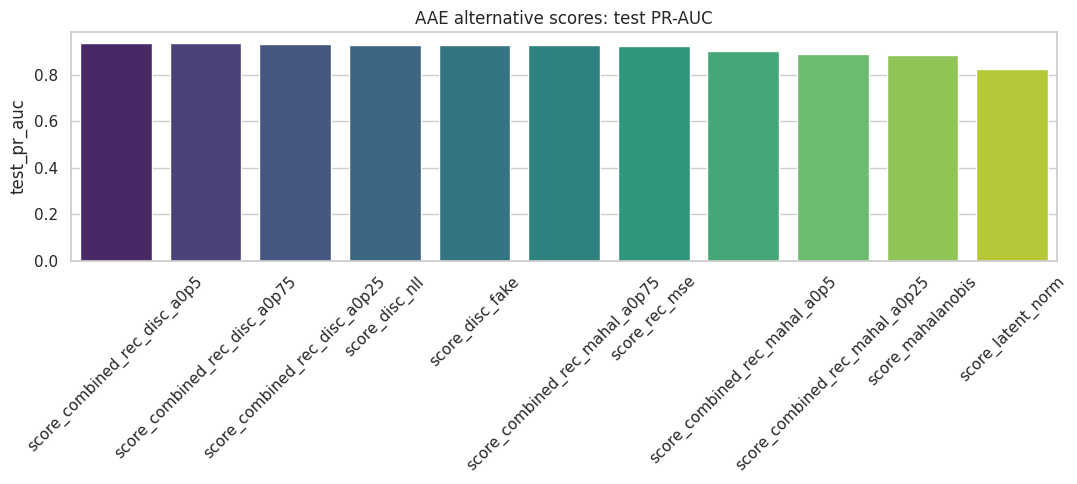

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_alternative_scores_f1_by_threshold.png


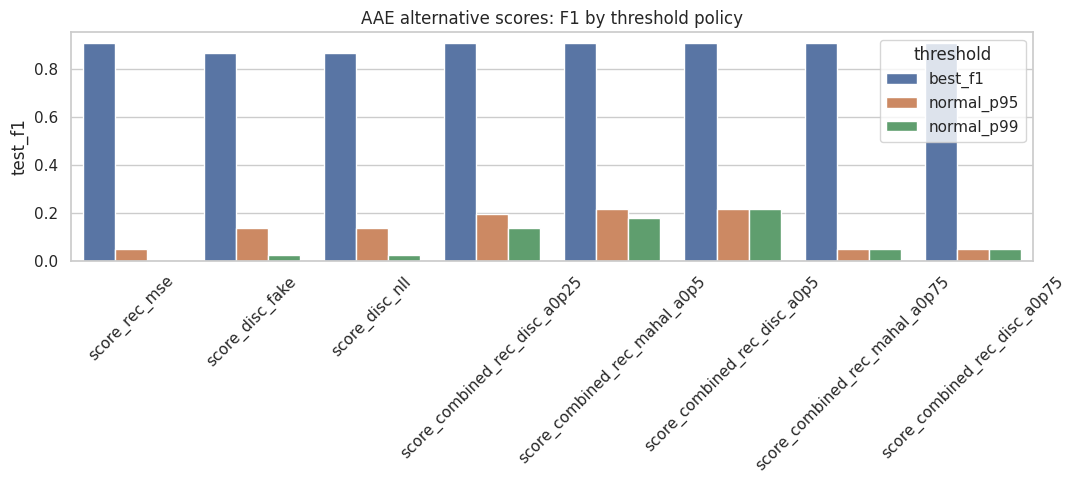

In [9]:
score_summary = score_eval.drop_duplicates('score').sort_values('test_pr_auc', ascending=False)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=score_summary.head(12), x='score', y='test_pr_auc', palette='viridis')
ax.set_title('AAE alternative scores: test PR-AUC')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
save_fig('aae_alternative_scores_pr_auc.png')
plt.show()

plt.figure(figsize=(11, 5))
plot_df = score_eval[score_eval['score'].isin(score_summary.head(8)['score'])]
ax = sns.barplot(data=plot_df, x='score', y='test_f1', hue='threshold_policy')
ax.set_title('AAE alternative scores: F1 by threshold policy')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='threshold')
save_fig('aae_alternative_scores_f1_by_threshold.png')
plt.show()

## 7. Confronto con AE MLP selezionato

Verifica se qualche score AAE supera AE MLP in PR-AUC/F1.

,model_or_score,test_pr_auc,test_roc_auc,test_f1,test_false_alarms_per_run
0,AE MLP reconstruction,0.916,0.648,0.907,0.167
1,AAE best: score_combined_rec_disc_a0p5,0.937,0.703,0.907,0.167


Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/ae_vs_best_aae_score.png


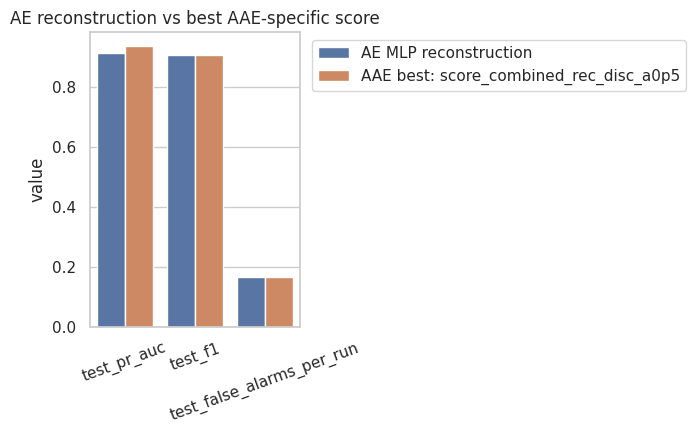

In [10]:
ae_val_scores = pd.DataFrame({
    'run_id': ae_val['run_ids'],
    'start': ae_val['starts'],
    'label': ae_val['y'],
    'score_rec_mse': ae_val['score_rec_mse'],
})
ae_test_scores = pd.DataFrame({
    'run_id': ae_test['run_ids'],
    'start': ae_test['starts'],
    'label': ae_test['y'],
    'score_rec_mse': ae_test['score_rec_mse'],
})
ae_threshold = select_threshold(ae_val_scores['label'].to_numpy(), ae_val_scores['score_rec_mse'].to_numpy(), method='best_f1')
ae_metrics = all_metrics(
    ae_test_scores['label'].to_numpy(),
    ae_test_scores['score_rec_mse'].to_numpy(),
    ae_threshold,
    ae_test_scores['run_id'].to_numpy(),
    ae_test_scores['start'].to_numpy(),
)
ae_pr_auc = average_precision_score(ae_test_scores['label'], ae_test_scores['score_rec_mse'])
ae_roc_auc = roc_auc_score(ae_test_scores['label'], ae_test_scores['score_rec_mse'])

comparison = pd.DataFrame([
    {
        'model_or_score': 'AE MLP reconstruction',
        'test_pr_auc': ae_pr_auc,
        'test_roc_auc': ae_roc_auc,
        'test_f1': ae_metrics['f1'],
        'test_false_alarms_per_run': ae_metrics.get('false_alarms_per_run'),
    },
    {
        'model_or_score': f'AAE best: {BEST_AAE_SCORE}',
        'test_pr_auc': best_score_row['test_pr_auc'],
        'test_roc_auc': best_score_row['test_roc_auc'],
        'test_f1': best_score_row['test_f1'],
        'test_false_alarms_per_run': best_score_row['test_false_alarms_per_run'],
    },
])
comparison.to_csv(TABLES_DIR / 'ae_vs_best_aae_score.csv', index=False)
display(comparison.style.format(precision=3))

plt.figure(figsize=(7, 4.5))
long = comparison.melt(id_vars='model_or_score', value_vars=['test_pr_auc', 'test_f1', 'test_false_alarms_per_run'], var_name='metric', value_name='value')
ax = sns.barplot(data=long, x='metric', y='value', hue='model_or_score')
ax.set_title('AE reconstruction vs best AAE-specific score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
save_fig('ae_vs_best_aae_score.png')
plt.show()

## 8. Distribuzioni score AAE-specifici

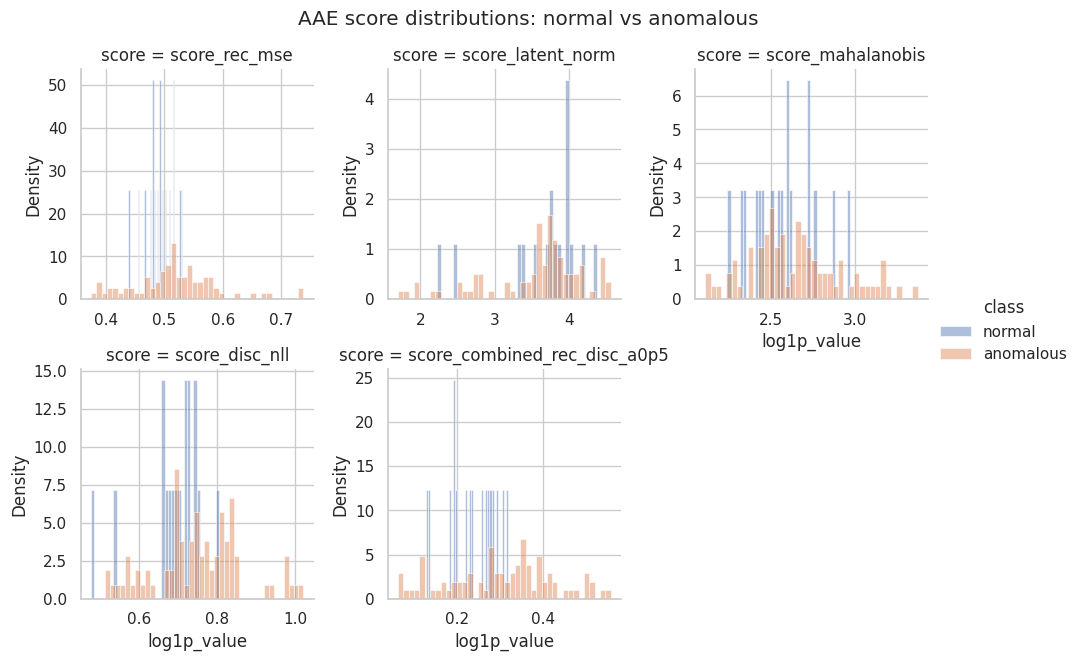

In [11]:
dist_cols = ['score_rec_mse', 'score_latent_norm', 'score_mahalanobis', 'score_disc_nll', BEST_AAE_SCORE]
dist_cols = list(dict.fromkeys([c for c in dist_cols if c in aae_test_scores.columns]))
plot_df = aae_test_scores[['label'] + dist_cols].copy()
plot_df['class'] = np.where(plot_df['label'] == 1, 'anomalous', 'normal')
long = plot_df.melt(id_vars=['label', 'class'], value_vars=dist_cols, var_name='score', value_name='value')
long['log1p_value'] = np.log1p(np.maximum(long['value'], 0))

g = sns.FacetGrid(long, col='score', hue='class', col_wrap=3, sharex=False, sharey=False, height=3.2)
g.map_dataframe(sns.histplot, x='log1p_value', stat='density', bins=40, alpha=0.45)
g.add_legend()
g.fig.suptitle('AAE score distributions: normal vs anomalous', y=1.03)
g.savefig(FIGURES_DIR / 'aae_score_distributions.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Latent-space analysis

PCA 2D dello spazio latente, istogrammi delle norme e distribuzioni delle dimensioni latenti.

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_latent_pca_by_label.png


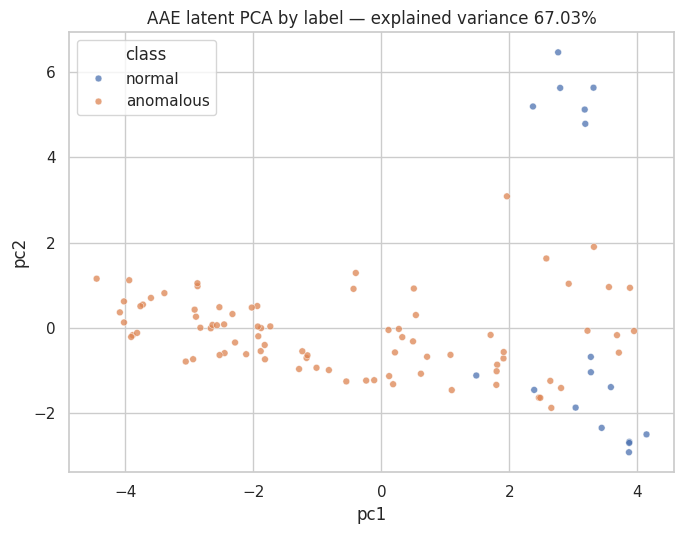

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_latent_pca_by_outcome.png


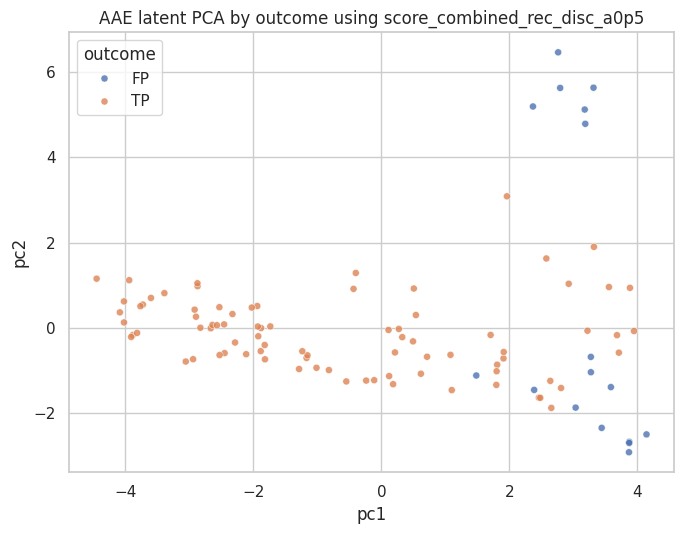

In [12]:
z_cols = [c for c in aae_test_scores.columns if c.startswith('z_')]
z_test = aae_test_scores[z_cols].to_numpy()
pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(z_test)
latent_plot = aae_test_scores[['run_id', 'start', 'label', BEST_AAE_SCORE]].copy()
latent_plot['pc1'] = coords[:, 0]
latent_plot['pc2'] = coords[:, 1]
latent_plot['class'] = np.where(latent_plot['label'] == 1, 'anomalous', 'normal')
latent_plot['pred_best'] = (latent_plot[BEST_AAE_SCORE] >= BEST_AAE_THRESHOLD).astype(int)
latent_plot['outcome'] = np.select(
    [
        (latent_plot['label'] == 0) & (latent_plot['pred_best'] == 0),
        (latent_plot['label'] == 0) & (latent_plot['pred_best'] == 1),
        (latent_plot['label'] == 1) & (latent_plot['pred_best'] == 0),
        (latent_plot['label'] == 1) & (latent_plot['pred_best'] == 1),
    ],
    ['TN', 'FP', 'FN', 'TP'],
    default='unknown',
)
latent_plot.to_csv(TABLES_DIR / 'aae_latent_pca_coordinates.csv', index=False)

plt.figure(figsize=(7, 5.5))
ax = sns.scatterplot(data=latent_plot, x='pc1', y='pc2', hue='class', alpha=0.75, s=24)
ax.set_title(f'AAE latent PCA by label — explained variance {pca.explained_variance_ratio_.sum():.2%}')
save_fig('aae_latent_pca_by_label.png')
plt.show()

plt.figure(figsize=(7, 5.5))
ax = sns.scatterplot(data=latent_plot, x='pc1', y='pc2', hue='outcome', alpha=0.8, s=26)
ax.set_title(f'AAE latent PCA by outcome using {BEST_AAE_SCORE}')
save_fig('aae_latent_pca_by_outcome.png')
plt.show()

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_latent_dimension_distributions.png


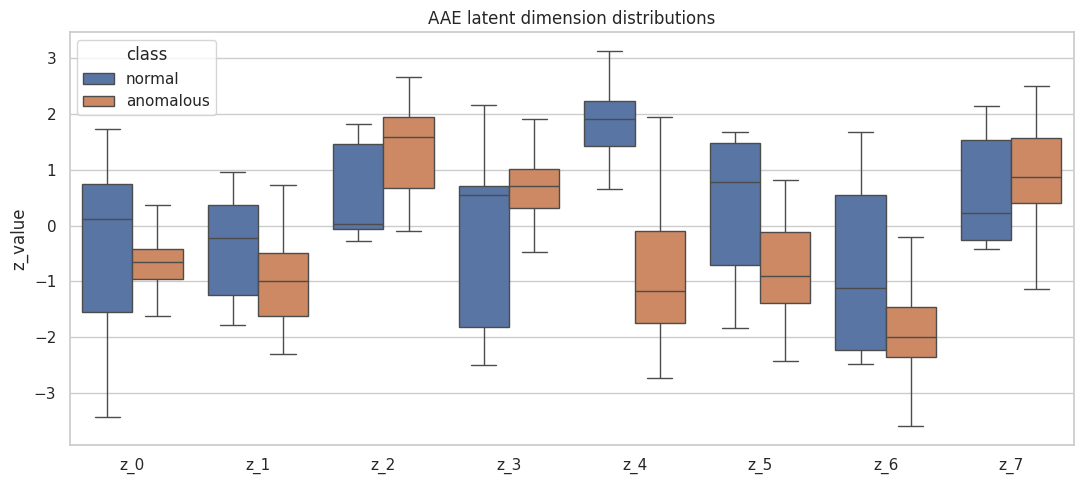

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_latent_disc_violin.png


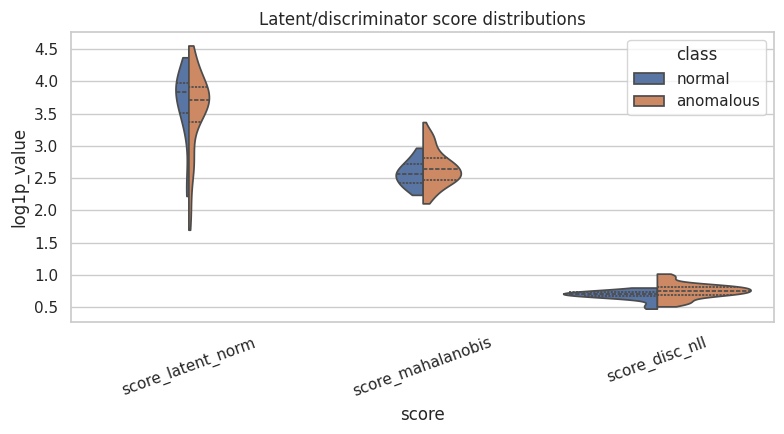

In [13]:
latent_dims = aae_test_scores[['label'] + z_cols].melt(id_vars='label', var_name='latent_dim', value_name='z_value')
latent_dims['class'] = np.where(latent_dims['label'] == 1, 'anomalous', 'normal')
keep_dims = z_cols[:min(8, len(z_cols))]

plt.figure(figsize=(11, 5))
ax = sns.boxplot(data=latent_dims[latent_dims['latent_dim'].isin(keep_dims)], x='latent_dim', y='z_value', hue='class', showfliers=False)
ax.set_title('AAE latent dimension distributions')
ax.set_xlabel('')
save_fig('aae_latent_dimension_distributions.png')
plt.show()

plt.figure(figsize=(8, 4.5))
norm_df = aae_test_scores[['label', 'score_latent_norm', 'score_mahalanobis', 'score_disc_nll']].copy()
norm_df['class'] = np.where(norm_df['label'] == 1, 'anomalous', 'normal')
long_norm = norm_df.melt(id_vars=['label', 'class'], value_vars=['score_latent_norm', 'score_mahalanobis', 'score_disc_nll'], var_name='score', value_name='value')
long_norm['log1p_value'] = np.log1p(np.maximum(long_norm['value'], 0))
ax = sns.violinplot(data=long_norm, x='score', y='log1p_value', hue='class', split=True, inner='quartile', cut=0)
ax.set_title('Latent/discriminator score distributions')
ax.tick_params(axis='x', rotation=20)
save_fig('aae_latent_disc_violin.png')
plt.show()

## 10. Mapping action e source_file

,run_id,action,source_file,label
0,normal_seg_1394,19.0,normal,0
1,normal_seg_1394,19.0,normal,0
2,normal_seg_1902,5.0,normal,0
3,normal_seg_1905,6.0,normal,0
4,normal_seg_1906,5.0,normal,0


Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/aae_latent_pca_by_action.png


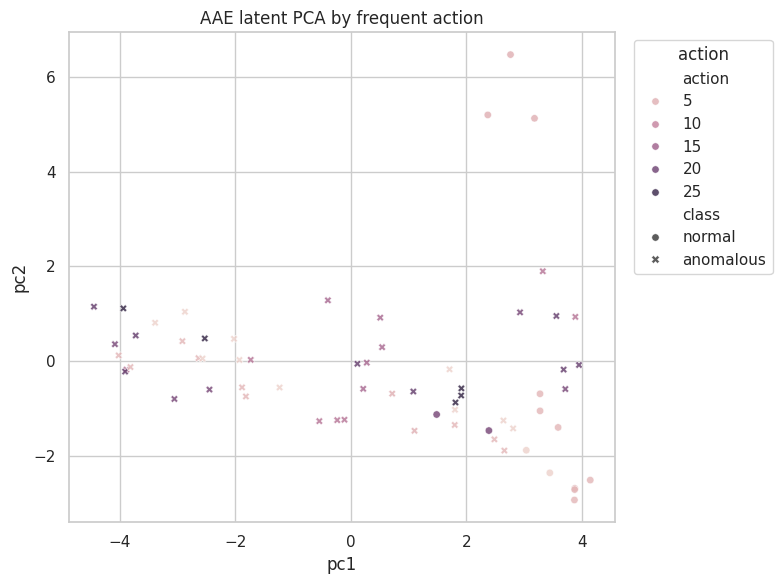

In [14]:
def load_dataset_summary_for_run(run_dir: Path) -> pd.DataFrame:
    candidates = [run_dir / 'dataset_summary.csv', RESULTS_ROOT / 'data_audit' / 'dataset_summary.csv']
    candidates.extend(RESULTS_ROOT.rglob('dataset_summary.csv'))
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            if {'run_id', 'action'}.issubset(df.columns):
                df['run_id'] = df['run_id'].astype(str)
                return df.drop_duplicates('run_id')
    raise FileNotFoundError('dataset_summary.csv con colonne run_id/action non trovato.')

dataset_summary = load_dataset_summary_for_run(BEST_AAE_DIR)
action_map = dataset_summary.set_index('run_id')['action'].to_dict() if 'action' in dataset_summary else {}
source_map = dataset_summary.set_index('run_id')['source_file'].to_dict() if 'source_file' in dataset_summary else {}

def add_action_source(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out['action'] = out['run_id'].map(action_map)
    out['source_file'] = out['run_id'].map(source_map)
    return out

aae_test_scores = add_action_source(aae_test_scores)
aae_val_scores = add_action_source(aae_val_scores)
ae_test_scores = add_action_source(ae_test_scores)
ae_val_scores = add_action_source(ae_val_scores)
latent_plot = add_action_source(latent_plot)
latent_plot.to_csv(TABLES_DIR / 'aae_latent_pca_coordinates.csv', index=False)

display(aae_test_scores[['run_id', 'action', 'source_file', 'label']].head())

top_latent_actions = latent_plot['action'].value_counts().head(8).index
latent_action_plot = latent_plot[latent_plot['action'].isin(top_latent_actions)].copy()
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(data=latent_action_plot, x='pc1', y='pc2', hue='action', style='class', alpha=0.8, s=28)
ax.set_title('AAE latent PCA by frequent action')
ax.legend(title='action', bbox_to_anchor=(1.02, 1), loc='upper left')
save_fig('aae_latent_pca_by_action.png')
plt.show()

## 11. Analisi per action

Verifica se AAE peggiora globalmente o solo su azioni specifiche.

In [15]:
def threshold_for_score(val_frame: pd.DataFrame, score_col: str, policy='best_f1'):
    if policy == 'best_f1':
        return select_threshold(val_frame['label'].to_numpy(), val_frame[score_col].to_numpy(), method='best_f1')
    if policy == 'normal_p95':
        return select_threshold(val_frame['label'].to_numpy(), val_frame[score_col].to_numpy(), method='normal_percentile', fallback_percentile=95.0)
    if policy == 'normal_p99':
        return select_threshold(val_frame['label'].to_numpy(), val_frame[score_col].to_numpy(), method='normal_percentile', fallback_percentile=99.0)
    raise ValueError(policy)

def per_action_metrics(frame: pd.DataFrame, score_col: str, threshold: float, label: str) -> pd.DataFrame:
    rows = []
    tmp = frame.dropna(subset=['action']).copy()
    tmp['pred'] = (tmp[score_col] >= threshold).astype(int)
    for action, part in tmp.groupby('action'):
        y = part['label'].to_numpy().astype(int)
        pred = part['pred'].to_numpy().astype(int)
        score_values = part[score_col].to_numpy()
        tp = int(((y == 1) & (pred == 1)).sum())
        fp = int(((y == 0) & (pred == 1)).sum())
        tn = int(((y == 0) & (pred == 0)).sum())
        fn = int(((y == 1) & (pred == 0)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-12)
        pr_auc = average_precision_score(y, score_values) if len(np.unique(y)) == 2 else np.nan
        roc_auc = roc_auc_score(y, score_values) if len(np.unique(y)) == 2 else np.nan
        rows.append({
            'detector': label,
            'action': action,
            'n_windows': len(part),
            'anomaly_rate': float(y.mean()),
            'pr_auc': pr_auc,
            'roc_auc': roc_auc,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn,
            'mean_score': float(part[score_col].mean()),
        })
    return pd.DataFrame(rows)

aae_rec_threshold = threshold_for_score(aae_val_scores, 'score_rec_mse')
aae_best_threshold = threshold_for_score(aae_val_scores, BEST_AAE_SCORE, BEST_AAE_THRESHOLD_POLICY)
ae_rec_threshold = threshold_for_score(ae_val_scores, 'score_rec_mse')

per_action = pd.concat([
    per_action_metrics(ae_test_scores, 'score_rec_mse', ae_rec_threshold, 'AE rec'),
    per_action_metrics(aae_test_scores, 'score_rec_mse', aae_rec_threshold, 'AAE rec'),
    per_action_metrics(aae_test_scores, BEST_AAE_SCORE, aae_best_threshold, f'AAE {BEST_AAE_SCORE}'),
], ignore_index=True)
per_action.to_csv(TABLES_DIR / 'per_action_metrics.csv', index=False)
display(per_action.sort_values(['detector', 'f1'], ascending=[True, True]).head(30).style.format(precision=3))

pivot_f1 = per_action.pivot_table(index='action', columns='detector', values='f1')
if {'AE rec', 'AAE rec'}.issubset(pivot_f1.columns):
    pivot_f1['AAE_rec_minus_AE_rec'] = pivot_f1['AAE rec'] - pivot_f1['AE rec']
    pivot_f1 = pivot_f1.sort_values('AAE_rec_minus_AE_rec')
    pivot_f1.to_csv(TABLES_DIR / 'per_action_f1_deltas.csv')
    display(pivot_f1.head(15).style.format(precision=3))

,detector,action,n_windows,anomaly_rate,pr_auc,roc_auc,precision,recall,f1,tp,fp,tn,fn,mean_score
30,AAE rec,9.000,2,0.000,nan,nan,0.000,0.000,0.000,0,2,0,0,0.636
26,AAE rec,5.000,5,0.400,0.325,0.000,0.400,1.000,0.571,2,3,0,0,0.616
25,AAE rec,4.000,16,0.562,0.739,0.730,0.562,1.000,0.720,9,7,0,0,0.651
27,AAE rec,6.000,3,0.667,0.583,0.000,0.667,1.000,0.800,2,1,0,0,0.594
37,AAE rec,19.000,7,0.714,0.876,0.600,0.714,1.000,0.833,5,2,0,0,0.649
23,AAE rec,1.000,12,0.833,1.000,1.000,0.833,1.000,0.909,10,2,0,0,0.671
24,AAE rec,3.000,3,1.000,nan,nan,1.000,1.000,1.000,3,0,0,0,0.671
28,AAE rec,7.000,1,1.000,nan,nan,1.000,1.000,1.000,1,0,0,0,0.732
29,AAE rec,8.000,2,1.000,nan,nan,1.000,1.000,1.000,2,0,0,0,0.727
31,AAE rec,10.000,4,1.000,nan,nan,1.000,1.000,1.000,4,0,0,0,0.679


detector,AAE rec,AAE score_combined_rec_disc_a0p5,AE rec,AAE_rec_minus_AE_rec
action,,,,
1.000000,0.909,0.909,0.909,0.000
3.000000,1.000,1.000,1.000,0.000
4.000000,0.720,0.720,0.720,0.000
5.000000,0.571,0.571,0.571,0.000
6.000000,0.800,0.800,0.800,0.000
7.000000,1.000,1.000,1.000,0.000
8.000000,1.000,1.000,1.000,0.000
9.000000,0.000,0.000,0.000,0.000
10.000000,1.000,1.000,1.000,0.000


Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/per_action_f1_frequent_actions.png


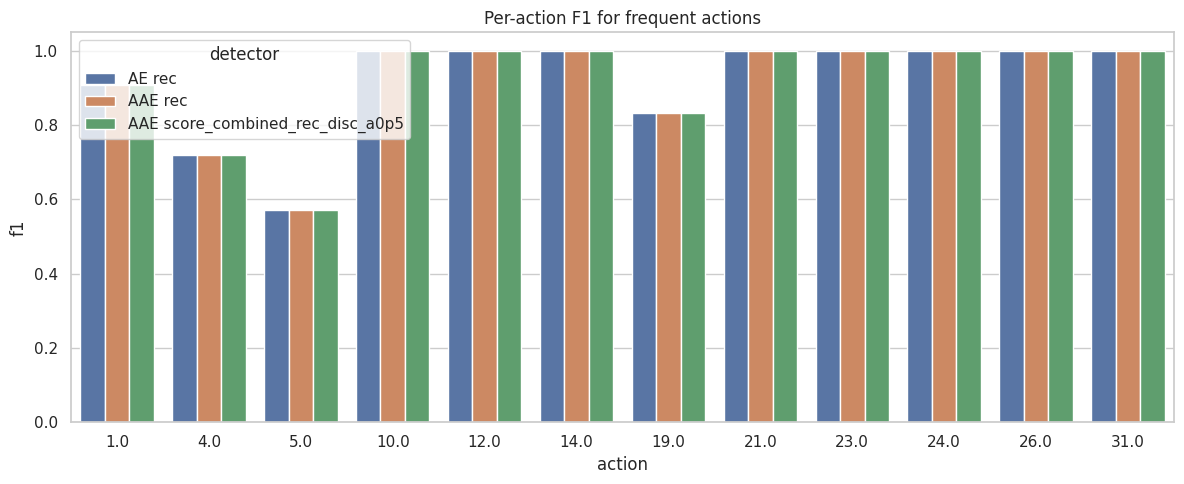

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/per_action_false_positives_frequent_actions.png


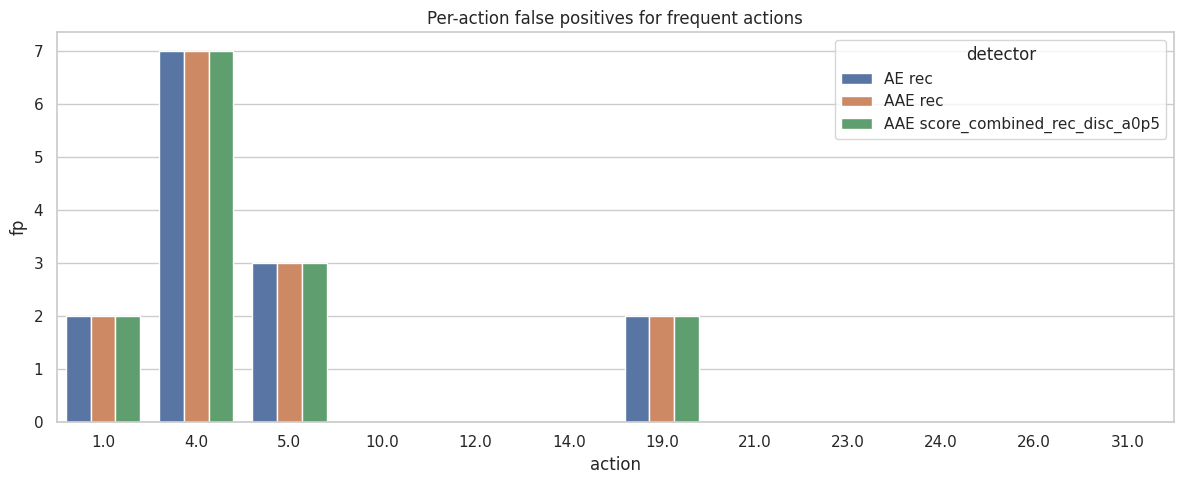

In [16]:
plot_actions = per_action.groupby('action')['n_windows'].max().sort_values(ascending=False).head(12).index
plot_df = per_action[per_action['action'].isin(plot_actions)]

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=plot_df, x='action', y='f1', hue='detector')
ax.set_title('Per-action F1 for frequent actions')
ax.set_xlabel('action')
save_fig('per_action_f1_frequent_actions.png')
plt.show()

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=plot_df, x='action', y='fp', hue='detector')
ax.set_title('Per-action false positives for frequent actions')
ax.set_xlabel('action')
save_fig('per_action_false_positives_frequent_actions.png')
plt.show()

## 12. Errore di ricostruzione per feature

Confronta AE e AAE: quali feature aumentano o riducono la separazione anomaly-normal?

In [17]:
def feature_error_summary(diag: dict, feature_cols: list[str], label: str, threshold: float | None = None, scores: np.ndarray | None = None) -> pd.DataFrame:
    y = diag['y'].astype(int)
    feature_err = diag['feature_mse']
    rows = []
    pred = None
    if threshold is not None and scores is not None:
        pred = (scores >= threshold).astype(int)
    for idx, feature in enumerate(feature_cols):
        normal_mean = float(feature_err[y == 0, idx].mean()) if (y == 0).any() else np.nan
        anomaly_mean = float(feature_err[y == 1, idx].mean()) if (y == 1).any() else np.nan
        row = {
            'model': label,
            'feature': feature,
            'normal_error': normal_mean,
            'anomaly_error': anomaly_mean,
            'separation': anomaly_mean - normal_mean,
        }
        if pred is not None:
            for outcome, mask in {
                'tn_error': (y == 0) & (pred == 0),
                'fp_error': (y == 0) & (pred == 1),
                'fn_error': (y == 1) & (pred == 0),
                'tp_error': (y == 1) & (pred == 1),
            }.items():
                row[outcome] = float(feature_err[mask, idx].mean()) if mask.any() else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

ae_feature_summary = feature_error_summary(ae_test, ae_test['feature_cols'], 'AE rec', ae_rec_threshold, ae_test['score_rec_mse'])
aae_feature_summary = feature_error_summary(aae_test, aae_test['feature_cols'], 'AAE rec', aae_rec_threshold, aae_test['score_rec_mse'])
feature_summary = pd.concat([ae_feature_summary, aae_feature_summary], ignore_index=True)
feature_summary.to_csv(TABLES_DIR / 'feature_reconstruction_error_summary.csv', index=False)

wide_features = ae_feature_summary[['feature', 'normal_error', 'anomaly_error', 'separation']].merge(
    aae_feature_summary[['feature', 'normal_error', 'anomaly_error', 'separation']],
    on='feature',
    suffixes=('_ae', '_aae'),
)
wide_features['delta_separation_aae_minus_ae'] = wide_features['separation_aae'] - wide_features['separation_ae']
wide_features['delta_normal_error_aae_minus_ae'] = wide_features['normal_error_aae'] - wide_features['normal_error_ae']
wide_features.to_csv(TABLES_DIR / 'feature_ae_aae_separation_deltas.csv', index=False)
display(wide_features.sort_values('delta_separation_aae_minus_ae').head(15).style.format(precision=5))

,feature,normal_error_ae,anomaly_error_ae,separation_ae,normal_error_aae,anomaly_error_aae,separation_aae,delta_separation_aae_minus_ae,delta_normal_error_aae_minus_ae
72,sensor_id6_q4,0.46039,0.25267,-0.20772,0.72420,0.24896,-0.47524,-0.26752,0.26380
5,machine_nameKuka Robot_power_factor,2.76649,1.75009,-1.01640,2.78803,1.52412,-1.26391,-0.24751,0.02155
3,machine_nameKuka Robot_phase_angle,2.27837,1.53295,-0.74542,2.28962,1.34018,-0.94944,-0.20402,0.01125
69,sensor_id6_q1,0.34232,0.53736,0.19504,0.52197,0.53646,0.01449,-0.18056,0.17966
2,machine_nameKuka Robot_frequency,1.70101,1.56974,-0.13127,1.79500,1.50275,-0.29224,-0.16098,0.09399
25,sensor_id2_q1,1.52258,0.66204,-0.86054,1.68554,0.67292,-1.01262,-0.15208,0.16297
27,sensor_id2_q3,0.96276,0.57564,-0.38712,1.19227,0.67101,-0.52127,-0.13415,0.22951
59,sensor_id5_q2,0.60925,1.12319,0.51394,0.75362,1.15382,0.40020,-0.11374,0.14436
60,sensor_id5_q3,0.28169,0.44298,0.16130,0.50513,0.59154,0.08641,-0.07489,0.22345
54,sensor_id5_AccZ,0.82677,0.76772,-0.05905,0.86343,0.74290,-0.12053,-0.06148,0.03666


Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/top_feature_error_separation.png


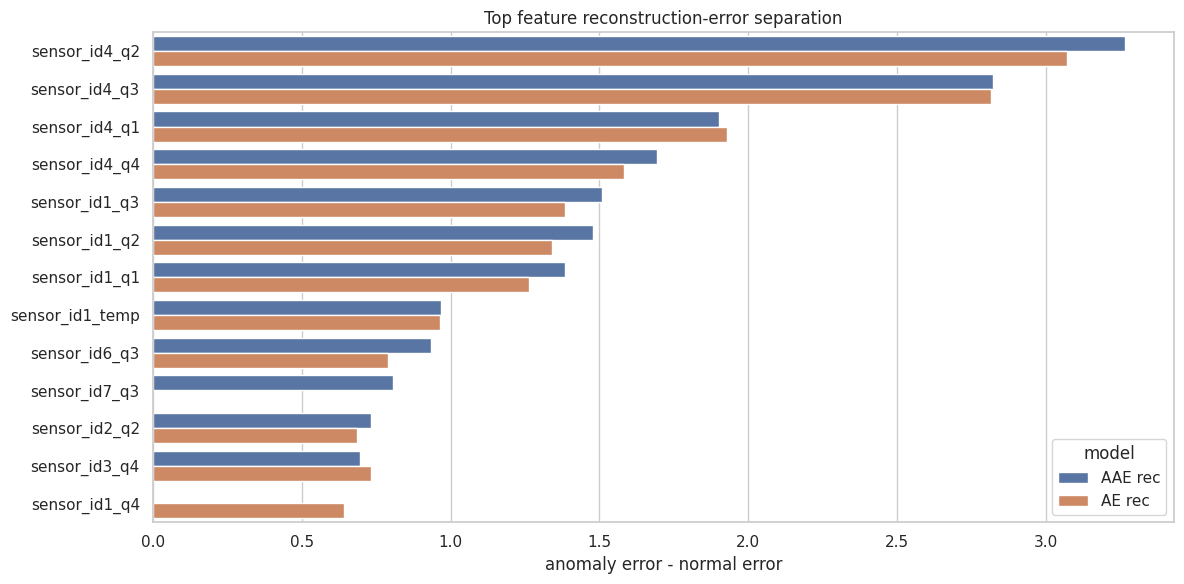

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/figures/features_where_aae_loses_separation.png


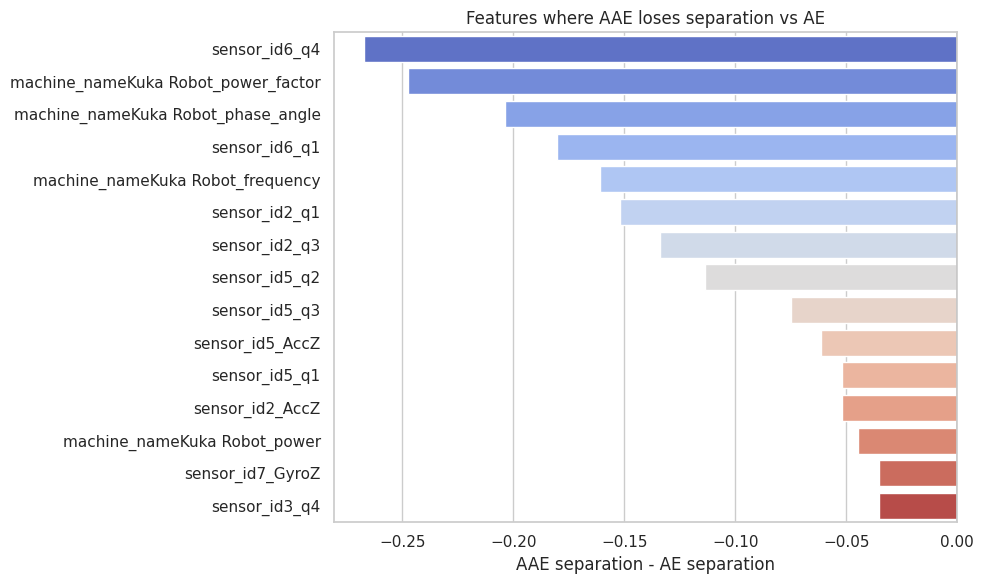

In [18]:
top_sep = feature_summary.sort_values('separation', ascending=False).groupby('model').head(12)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_sep, y='feature', x='separation', hue='model')
ax.set_title('Top feature reconstruction-error separation')
ax.set_xlabel('anomaly error - normal error')
ax.set_ylabel('')
save_fig('top_feature_error_separation.png')
plt.show()

worst_delta = wide_features.sort_values('delta_separation_aae_minus_ae').head(15)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=worst_delta, y='feature', x='delta_separation_aae_minus_ae', palette='coolwarm')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Features where AAE loses separation vs AE')
ax.set_xlabel('AAE separation - AE separation')
ax.set_ylabel('')
save_fig('features_where_aae_loses_separation.png')
plt.show()

## 13. Sintesi automatica Phase 3

In [19]:
best_alt = score_eval.sort_values(['test_pr_auc', 'test_f1'], ascending=False).iloc[0]
aae_rec = score_eval[(score_eval['score'] == 'score_rec_mse') & (score_eval['threshold_policy'] == 'best_f1')].iloc[0]
beats_ae_pr = bool(best_alt['test_pr_auc'] > ae_pr_auc)
beats_ae_f1 = bool(best_alt['test_f1'] > ae_metrics['f1'])

problem_actions = []
if 'pivot_f1' in globals() and 'AAE_rec_minus_AE_rec' in pivot_f1.columns:
    problem_actions = [str(a) for a in pivot_f1.head(5).index.tolist()]

lost_features = wide_features.sort_values('delta_separation_aae_minus_ae').head(8)['feature'].tolist()
problem_actions_text = ', '.join(problem_actions) if problem_actions else 'n/a'
lost_features_text = ', '.join(lost_features)

summary_lines = [
    '# Phase 3 AAE diagnostics summary',
    '',
    f'- Selected AE run: `{BEST_AE_DIR}`',
    f'- Selected AAE run: `{BEST_AAE_DIR}`',
    f"- AAE reconstruction PR-AUC: {aae_rec['test_pr_auc']:.4f}; F1(best-val): {aae_rec['test_f1']:.4f}",
    f"- Best AAE-specific score: `{best_alt['score']}` with `{best_alt['threshold_policy']}` threshold.",
    f"- Best AAE-specific PR-AUC: {best_alt['test_pr_auc']:.4f}; F1: {best_alt['test_f1']:.4f}; false alarms/run: {best_alt['test_false_alarms_per_run']:.4f}",
    f"- AE reconstruction PR-AUC: {ae_pr_auc:.4f}; F1: {ae_metrics['f1']:.4f}; false alarms/run: {ae_metrics.get('false_alarms_per_run'):.4f}",
    f'- Does any AAE score beat AE PR-AUC? {beats_ae_pr}',
    f'- Does any AAE score beat AE F1? {beats_ae_f1}',
    f'- Most problematic actions for AAE rec vs AE rec: {problem_actions_text}',
    f'- Features where AAE loses most reconstruction-error separation: {lost_features_text}',
    '',
    'Interpretation guidance:',
    '- If latent/discriminator/combined scores do not beat AE, the negative AAE conclusion is stronger.',
    '- If combined scores beat reconstruction but not AE, AAE contains some useful latent signal but not enough to justify the added complexity.',
    '- If AAE failures concentrate in specific actions, this supports the hypothesis that a single Gaussian prior is too restrictive for multimodal robot actions.',
]
summary_md = '\n'.join(summary_lines)
(PHASE3_ROOT / 'phase3_aae_diagnostics_summary.md').write_text(summary_md, encoding='utf-8')
display(Markdown(summary_md))
print('Saved:', PHASE3_ROOT / 'phase3_aae_diagnostics_summary.md')

# Phase 3 AAE diagnostics summary

- Selected AE run: `/content/drive/MyDrive/AM01/results/runs/ablation/ae_mlp_seed2_w128_z32`
- Selected AAE run: `/content/drive/MyDrive/AM01/results/runs/ablation/aae_mlp_seed2_w128_z16_lam0.1`
- AAE reconstruction PR-AUC: 0.9252; F1(best-val): 0.9071
- Best AAE-specific score: `score_combined_rec_disc_a0p5` with `best_f1` threshold.
- Best AAE-specific PR-AUC: 0.9371; F1: 0.9071; false alarms/run: 0.1667
- AE reconstruction PR-AUC: 0.9164; F1: 0.9071; false alarms/run: 0.1667
- Does any AAE score beat AE PR-AUC? True
- Does any AAE score beat AE F1? False
- Most problematic actions for AAE rec vs AE rec: 1.0, 3.0, 4.0, 5.0, 6.0
- Features where AAE loses most reconstruction-error separation: sensor_id6_q4, machine_nameKuka Robot_power_factor, machine_nameKuka Robot_phase_angle, sensor_id6_q1, machine_nameKuka Robot_frequency, sensor_id2_q1, sensor_id2_q3, sensor_id5_q2

Interpretation guidance:
- If latent/discriminator/combined scores do not beat AE, the negative AAE conclusion is stronger.
- If combined scores beat reconstruction but not AE, AAE contains some useful latent signal but not enough to justify the added complexity.
- If AAE failures concentrate in specific actions, this supports the hypothesis that a single Gaussian prior is too restrictive for multimodal robot actions.

Saved: /content/drive/MyDrive/AM01/results/phase3_aae_diagnostics/phase3_aae_diagnostics_summary.md


## 14. Manifest artefatti

In [20]:
artifacts = sorted([p for p in PHASE3_ROOT.rglob('*') if p.is_file()])
display(pd.DataFrame({'artifact': [str(p.relative_to(PHASE3_ROOT)) for p in artifacts]}))

,artifact
0,extended_scores/aae_extended_scores_test.csv
1,extended_scores/aae_extended_scores_val.csv
2,figures/aae_alternative_scores_f1_by_threshold...
3,figures/aae_alternative_scores_pr_auc.png
4,figures/aae_latent_dimension_distributions.png
5,figures/aae_latent_disc_violin.png
6,figures/aae_latent_pca_by_action.png
7,figures/aae_latent_pca_by_label.png
8,figures/aae_latent_pca_by_outcome.png
9,figures/aae_score_distributions.png
